# **Klasifikasi Jenis Kelamin Penguin | K-Means Clustering**

Model klasifikasi jenis kelamin penguin menggunakan algoritma K-Means Clustering

## 1. Data Preparation

### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

### 1.2 Read Dataset

In [2]:
df = pd.read_csv('penguins.csv')

In [3]:
# 5 baris teratas
print('5 baris teratas:')
df.head()

5 baris teratas:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
# 10 baris acak
print('10 baris acak:')
df.sample(10)

10 baris acak:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
223,50.0,15.2,218.0,5700.0,MALE
2,40.3,18.0,195.0,3250.0,FEMALE
329,48.1,15.1,209.0,5500.0,MALE
208,45.2,16.6,191.0,3250.0,FEMALE
38,37.6,19.3,181.0,3300.0,FEMALE
65,41.6,18.0,192.0,3950.0,MALE
301,52.5,15.6,221.0,5450.0,MALE
145,39.0,18.7,185.0,3650.0,MALE
114,39.6,20.7,191.0,3900.0,FEMALE
160,46.0,18.9,195.0,4150.0,FEMALE


In [5]:
# Ringkasan informasi
print('Ringkasan informasi dataset:\n')
df.info()

Ringkasan informasi dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [6]:
# Ringkasan statistik
print('Ringkasan statistik dataset:\n')
df.describe()

Ringkasan statistik dataset:



,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


### 1.3 Missing Value

#### 1.3.1 Cek Missing Value

In [7]:
# Total missing value
print('Total missing value:', df.isnull().sum().sum())

Total missing value: 17


In [8]:
# jumlah missing value setiap fitur
print('Jumlah missing value setiap fitur:\n') 
df.isnull().sum()

Jumlah missing value setiap fitur:



culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [9]:
df['sex'].value_counts()

sex
MALE      169
FEMALE    165
.           1
Name: count, dtype: int64

In [10]:
df['sex'] = df['sex'].replace('.', 'MALE')


In [11]:
df['sex'].unique()

array(['MALE', 'FEMALE', nan], dtype=object)

In [12]:
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])


In [13]:
df['sex'].value_counts(dropna=False)




sex
MALE      179
FEMALE    165
Name: count, dtype: int64

#### 1.3.2 Penanganan Missing Value

In [14]:
# Menangani missing value pada kolom numerik dengan median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [15]:
# Menangani missing value pada kolom object dengan modus
num_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [16]:
print('Jumlah nilai kosong setelah ditangani:', df.isnull().sum().sum())

Jumlah nilai kosong setelah ditangani: 0


### 1.4 Data Duplikat

In [17]:
# Total data duplikat
print('Total data duplikat:', df.duplicated().sum())

Total data duplikat: 1


In [18]:
# Menangani nilai duplikat
df = df.drop_duplicates(keep='first')



In [19]:
print('Total data duplikat setelah ditangani:', df.duplicated().sum())


Total data duplikat setelah ditangani: 0


### 1.5 Encoding 

In [20]:
# Encoding fitur 'sex'

df['sex'] = df['sex'].map({
    'MALE' : 1,
    'FEMALE' : 0,
})

In [21]:
df.dtypes

culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int64
dtype: object

## 2. Exploratory Data Analysis

### 2.1 Distriibusi Data

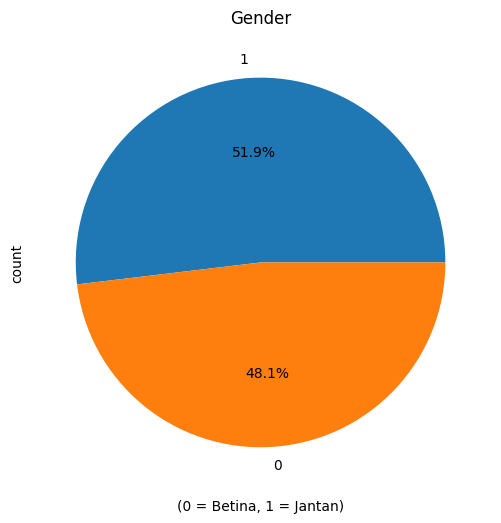

In [22]:
# Grafik Pie
plt.figure(figsize=(8,6))
df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender')
plt.xlabel('(0 = Betina, 1 = Jantan)')
plt.show()


### 2.2 Outlier

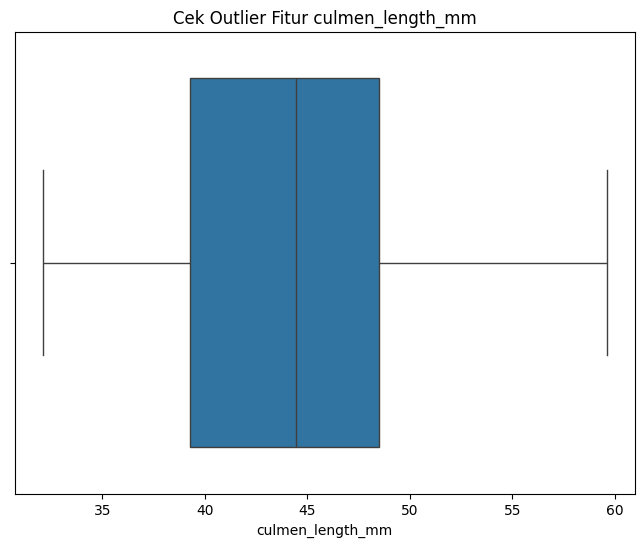

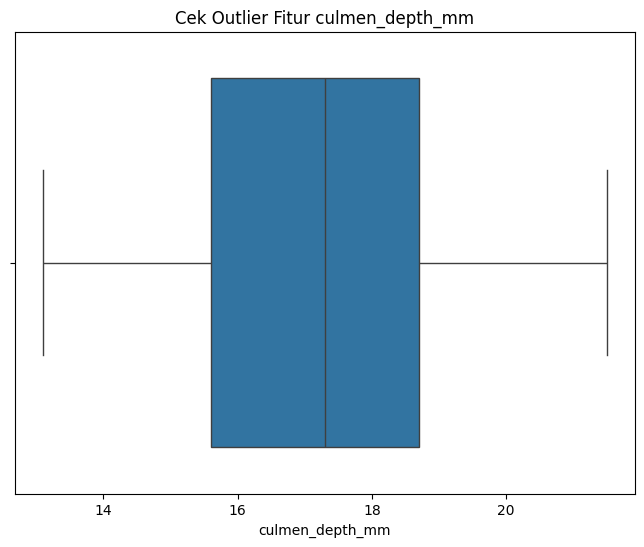

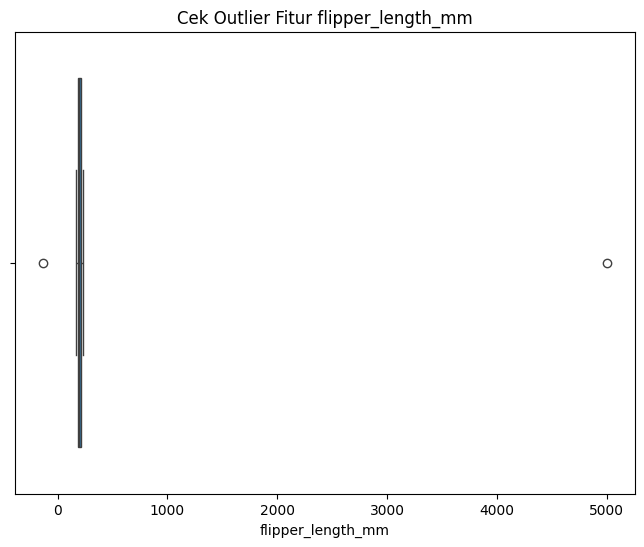

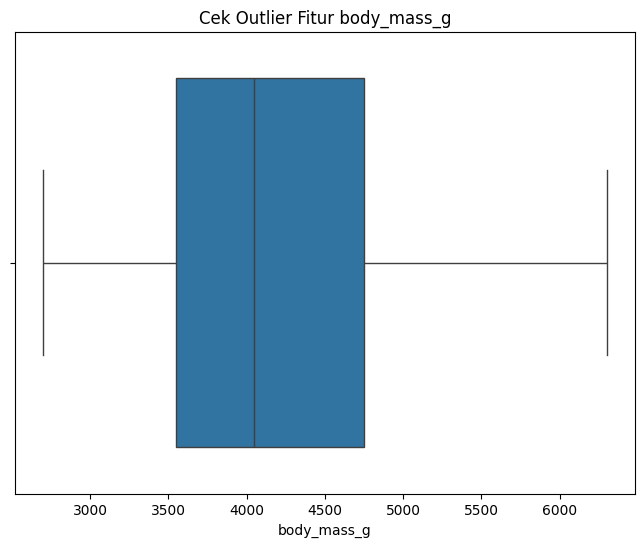

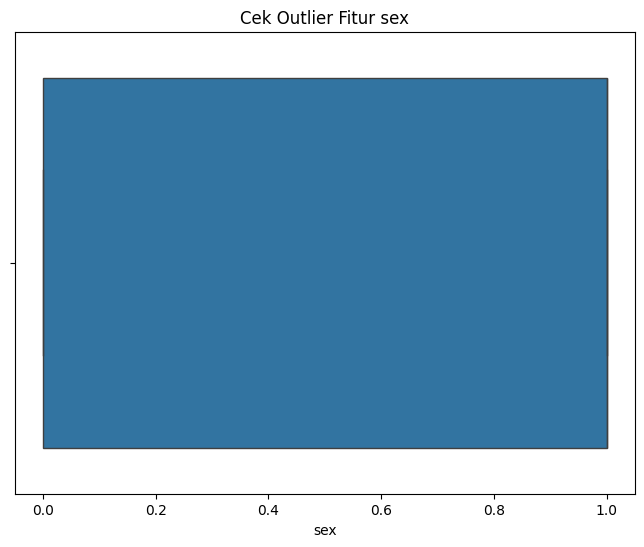

In [23]:
idx = 0
for col in df.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'Cek Outlier Fitur {df.columns[idx]}')
    idx += 1
    plt.show()


In [24]:

# Perulangan untuk cek outlier masing - masing kolom
for col in df.columns:

    # Menentukan kuartil atas dan bawah
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
     
    # Menghitung interquartil
    IQR = Q3 - Q1 

    # Menentukan batas atas dan bawah
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    # Menghitung jumlah outlier
    outlier = (df[col] < batas_bawah) | (df[col] > batas_atas)
    outlier_count = outlier.sum()

    print(f"Kolom = {col}") 
    print(f'Jumlah outlier = {outlier_count}\n')

    # Mengubah outlier menjadi median
    median_fix = df[col].median()

    df.loc[outlier, col] = median_fix
    

Kolom = culmen_length_mm
Jumlah outlier = 0

Kolom = culmen_depth_mm
Jumlah outlier = 0

Kolom = flipper_length_mm
Jumlah outlier = 2

Kolom = body_mass_g
Jumlah outlier = 0

Kolom = sex
Jumlah outlier = 0



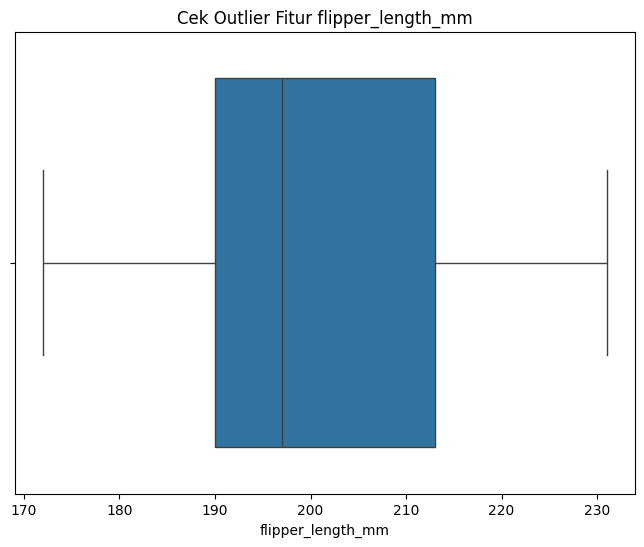

In [25]:
# Cek ulang outlier
plt.figure(figsize=(8,6))
sns.boxplot(x=df['flipper_length_mm'])
plt.title(f'Cek Outlier Fitur flipper_length_mm')
plt.show()

## 3. Model

In [26]:
X = df.drop('sex', axis=1).values
y = df['sex'].values

In [27]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_scaled = (X - mean) / std

# X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))


In [28]:
def K(data, k=2, max_iteration=100):
    n_samples, n_features = data.shape
    random_idx = np.random.choice(n_samples, k, replace=False)
    centroids = data[random_idx]

    for i in range(max_iteration):
        clusters = [[] for _ in range(k)]
        cluster_labels = []

        for point in data:
            d = [np.sqrt(np.sum((point - c)**2)) for c in centroids]
            cluster_idx = np.argmin(d)
            clusters[cluster_idx].append(point)
            cluster_labels.append(cluster_idx)
        old_centroids = centroids.copy()

        for idx in range(k):
            if clusters[idx]:
                centroids[idx] = np.mean(clusters[idx], axis=0)

        if np.all(old_centroids == centroids):
                break
        
    final_sse = 0
    for point in data:
         d2 = [np.sum((point - c)**2) for c in centroids]
         final_sse += np.min(d2)

    return cluster_labels, centroids, final_sse

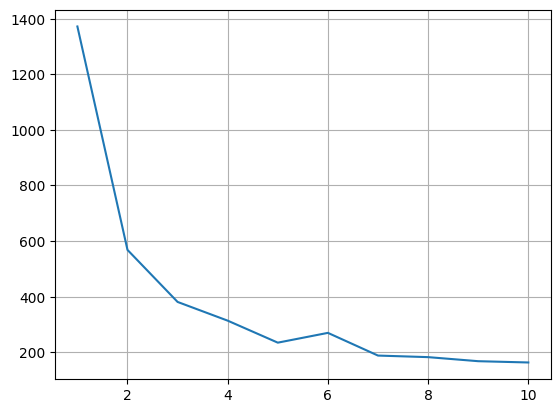

In [29]:
sse_score = []
k_range = range(1,11)

for k in k_range:
    _, _, sse = K(X_scaled, k=k)
    sse_score.append(sse)

plt.plot(k_range, sse_score)
plt.grid(True)
plt.show()

In [30]:
sse_score

[np.float64(1371.9999999999995),
 np.float64(568.3334430294549),
 np.float64(381.1217424889454),
 np.float64(313.7768092553945),
 np.float64(234.6547974279828),
 np.float64(269.8702353446261),
 np.float64(188.2145057739917),
 np.float64(182.57255692301467),
 np.float64(167.96587104743355),
 np.float64(163.35310192847462)]

## 4. Evaluasi 

## 5. Visualisasi